# Customer Churn Analysis

## Project Overview

This project analyzes customer churn behavior using Python.
The analysis focuses on customer demographics, tenure, balance,
product usage, credit card ownership, activity status, and estimated salary.

### Objectives
- Understand customer churn patterns
- Identify factors associated with customer churn
- Perform exploratory data analysis (EDA)
- Generate business insights
- Provide recommendations for customer retention

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import os

dataset_folder = "../01_Dataset"

print("Files available in 01_Dataset:")
print()

for root, dirs, files in os.walk(dataset_folder):
    for file in files:
        print(os.path.join(root, file))

Files available in 01_Dataset:

../01_Dataset\Cleaned_Data.xlsx
../01_Dataset\Customer_Churn_Analysis.xlsx
../01_Dataset\Customer_Churn_Data.csv
../01_Dataset\Raw_Data.xlsx


In [4]:
# Load customer churn dataset

file_path = "../01_Dataset/Customer_Churn_Data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1000, 11)


In [5]:
# Preview the dataset

print("First 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

First 5 rows:


,CustomerID,Age,Gender,Tenure_Months,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn,Duplicate_Check
0,1,56,Male,40,41393.42,3,1,1,101505.90,0,1
1,2,69,Male,45,39385.65,2,1,0,125091.33,0,1
2,3,46,Male,62,31221.27,2,0,1,99514.03,0,1
3,4,32,Female,58,24724.06,3,0,1,58447.18,0,1
4,5,60,Male,67,48977.54,3,1,1,53246.68,0,1



Column names:
['CustomerID', 'Age', 'Gender', 'Tenure_Months', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Churn', 'Duplicate_Check']


In [6]:
# Check missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
CustomerID         0
Age                0
Gender             0
Tenure_Months      0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Churn              0
Duplicate_Check    0
dtype: int64


In [7]:
# Check duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [8]:
# Statistical summary

df.describe()

,CustomerID,Age,Tenure_Months,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn,Duplicate_Check
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.0
mean,500.500000,43.81900,34.627000,25317.425970,2.485000,0.507000,0.50000,83865.806200,0.017000,1.0
std,288.819436,14.99103,20.334782,14553.200844,1.099538,0.500201,0.50025,37269.350343,0.129336,0.0
min,1.000000,18.00000,1.000000,9.420000,1.000000,0.000000,0.00000,20120.820000,0.000000,1.0
25%,250.750000,31.00000,17.000000,12678.457500,2.000000,0.000000,0.00000,51720.447500,0.000000,1.0
50%,500.500000,44.00000,33.500000,25944.675000,2.000000,1.000000,0.50000,83361.400000,0.000000,1.0
75%,750.250000,56.00000,52.000000,37996.107500,3.000000,1.000000,1.00000,116665.857500,0.000000,1.0
max,1000.000000,69.00000,71.000000,49985.690000,4.000000,1.000000,1.00000,149677.360000,1.000000,1.0


In [9]:
# Churn distribution

print("Churn Distribution:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn Distribution:
Churn
0    983
1     17
Name: count, dtype: int64

Churn Percentage:
Churn
0    98.3
1     1.7
Name: proportion, dtype: float64


In [10]:
# Check data types

print(df.dtypes)

CustomerID           int64
Age                  int64
Gender                 str
Tenure_Months        int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Churn                int64
Duplicate_Check      int64
dtype: object


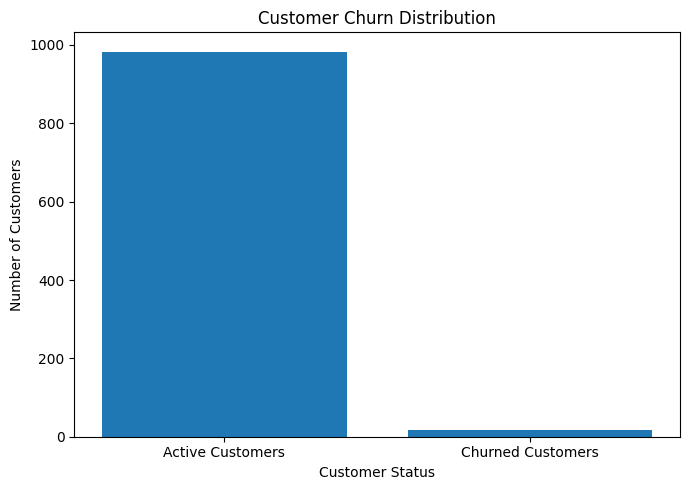

In [11]:
# Churn Distribution

churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(
    ["Active Customers", "Churned Customers"],
    [churn_counts.get(0, 0), churn_counts.get(1, 0)]
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Churn     0   1
Gender         
Female  466  10
Male    517   7


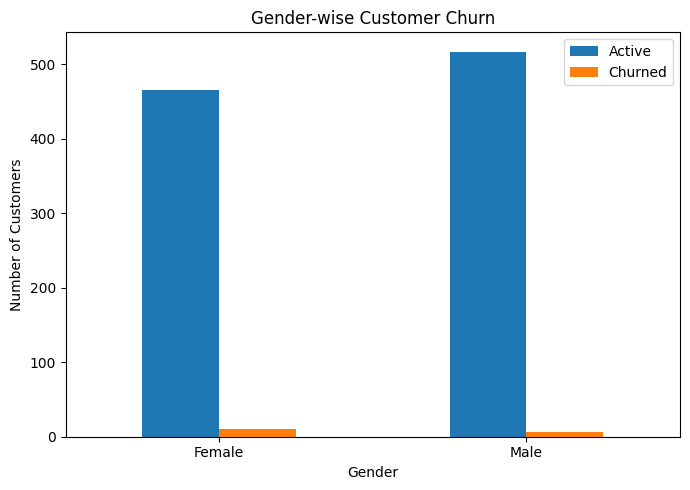

In [12]:
# Gender-wise Churn Analysis

gender_churn = pd.crosstab(df["Gender"], df["Churn"])

print(gender_churn)

gender_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Gender-wise Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(["Active", "Churned"])
plt.tight_layout()
plt.show()

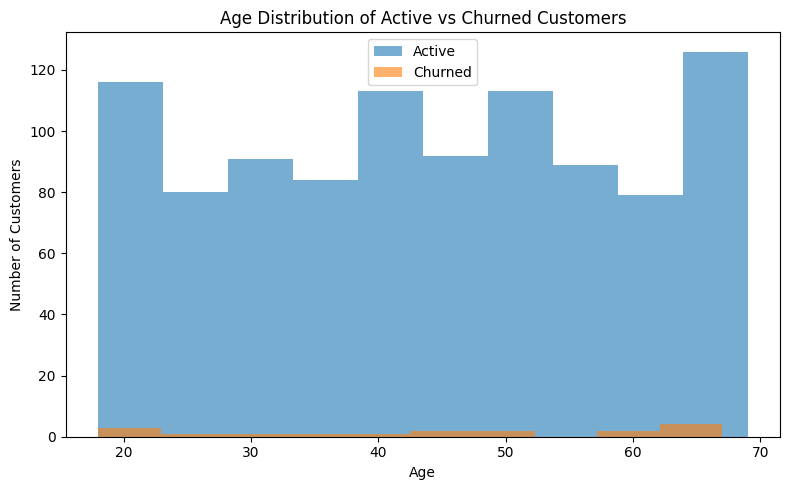

In [13]:
# Age-wise Churn Analysis

plt.figure(figsize=(8, 5))

plt.hist(
    df[df["Churn"] == 0]["Age"],
    bins=10,
    alpha=0.6,
    label="Active"
)

plt.hist(
    df[df["Churn"] == 1]["Age"],
    bins=10,
    alpha=0.6,
    label="Churned"
)

plt.title("Age Distribution of Active vs Churned Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.legend()
plt.tight_layout()
plt.show()

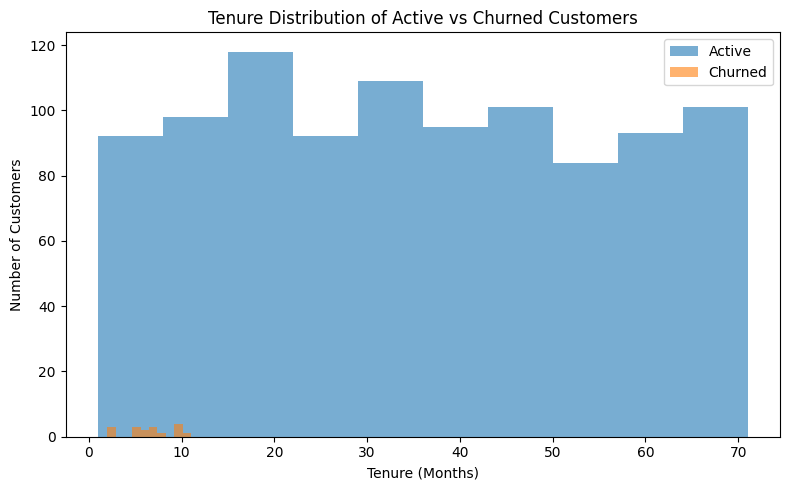

In [14]:
# Tenure-wise Churn Analysis

plt.figure(figsize=(8, 5))

plt.hist(
    df[df["Churn"] == 0]["Tenure_Months"],
    bins=10,
    alpha=0.6,
    label="Active"
)

plt.hist(
    df[df["Churn"] == 1]["Tenure_Months"],
    bins=10,
    alpha=0.6,
    label="Churned"
)

plt.title("Tenure Distribution of Active vs Churned Customers")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.legend()
plt.tight_layout()
plt.show()

Churn            0  1
NumOfProducts        
1              241  4
2              257  2
3              260  2
4              225  9


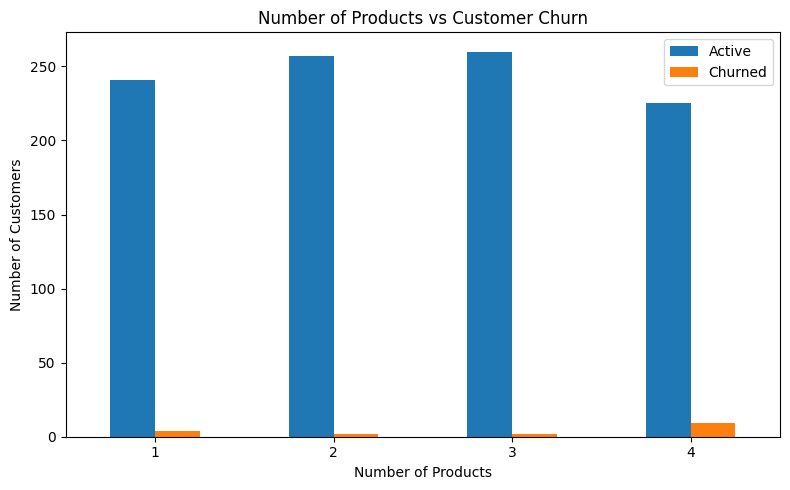

In [15]:
# Number of Products vs Churn

product_churn = pd.crosstab(df["NumOfProducts"], df["Churn"])

print(product_churn)

product_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Number of Products vs Customer Churn")
plt.xlabel("Number of Products")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(["Active", "Churned"])
plt.tight_layout()
plt.show()

Churn             0   1
IsActiveMember         
0               483  17
1               500   0


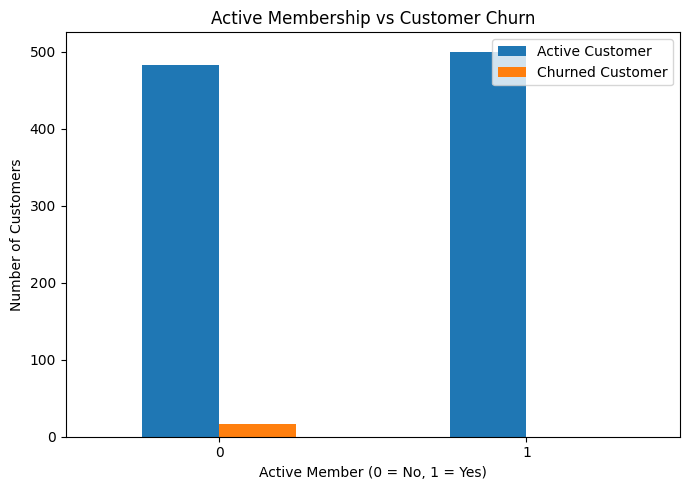

In [16]:
# Active Member vs Churn

active_churn = pd.crosstab(
    df["IsActiveMember"],
    df["Churn"]
)

print(active_churn)

active_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Active Membership vs Customer Churn")
plt.xlabel("Active Member (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(["Active Customer", "Churned Customer"])
plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_15620\3935124668.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


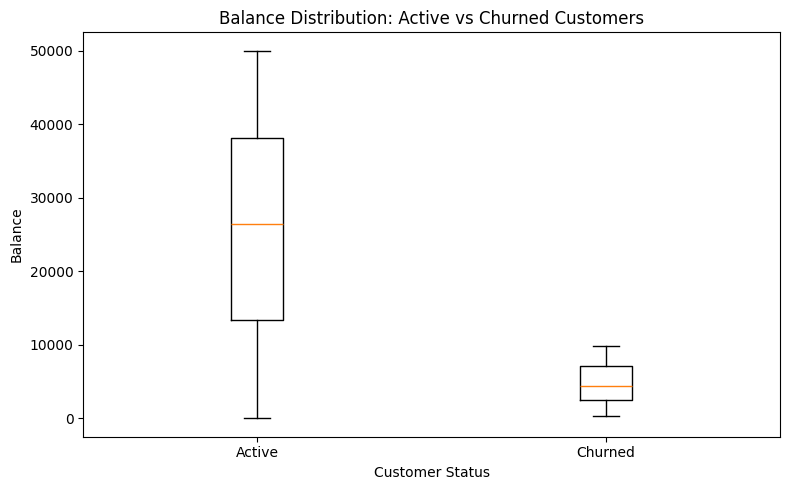

In [17]:
# Balance vs Churn

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df[df["Churn"] == 0]["Balance"],
        df[df["Churn"] == 1]["Balance"]
    ],
    labels=["Active", "Churned"]
)

plt.title("Balance Distribution: Active vs Churned Customers")
plt.xlabel("Customer Status")
plt.ylabel("Balance")
plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_15620\3734561922.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


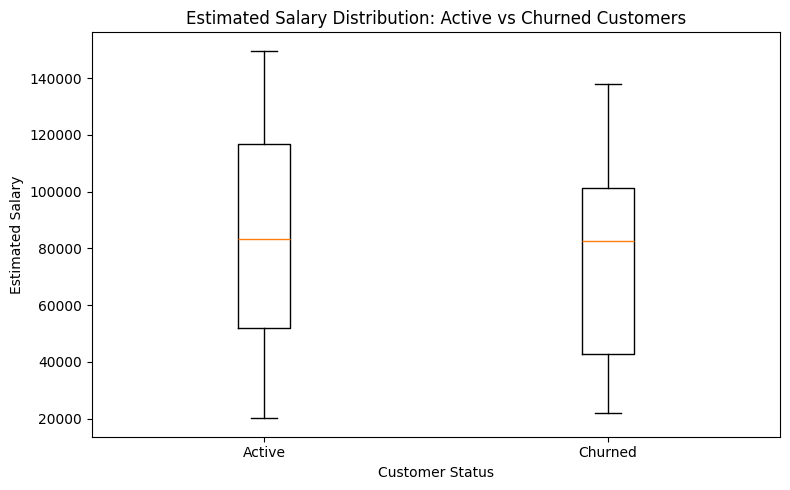

In [18]:
# Estimated Salary vs Churn

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df[df["Churn"] == 0]["EstimatedSalary"],
        df[df["Churn"] == 1]["EstimatedSalary"]
    ],
    labels=["Active", "Churned"]
)

plt.title("Estimated Salary Distribution: Active vs Churned Customers")
plt.xlabel("Customer Status")
plt.ylabel("Estimated Salary")
plt.tight_layout()
plt.show()

Churn        0   1
HasCrCard         
0          487   6
1          496  11


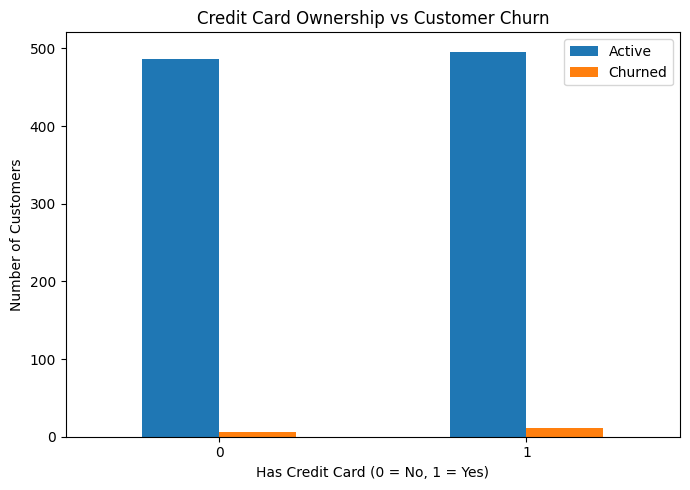

In [19]:
# Credit Card Ownership vs Churn

credit_churn = pd.crosstab(
    df["HasCrCard"],
    df["Churn"]
)

print(credit_churn)

credit_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Credit Card Ownership vs Customer Churn")
plt.xlabel("Has Credit Card (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(["Active", "Churned"])
plt.tight_layout()
plt.show()

In [20]:
# Churn Rate by Number of Products

product_churn_rate = (
    df.groupby("NumOfProducts")["Churn"]
    .mean()
    .mul(100)
    .round(2)
)

print("Churn Rate by Number of Products:")
print(product_churn_rate)

Churn Rate by Number of Products:
NumOfProducts
1    1.63
2    0.77
3    0.76
4    3.85
Name: Churn, dtype: float64


In [21]:
# Correlation Analysis

numeric_columns = [
    "Age",
    "Tenure_Months",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
    "Churn"
]

correlation = df[numeric_columns].corr()

print("Correlation with Churn:")
print(correlation["Churn"].sort_values(ascending=False))

Correlation with Churn:
Churn              1.000000
NumOfProducts      0.054587
HasCrCard          0.036841
Age                0.007784
EstimatedSalary   -0.016949
IsActiveMember    -0.131507
Tenure_Months     -0.181039
Balance           -0.185596
Name: Churn, dtype: float64


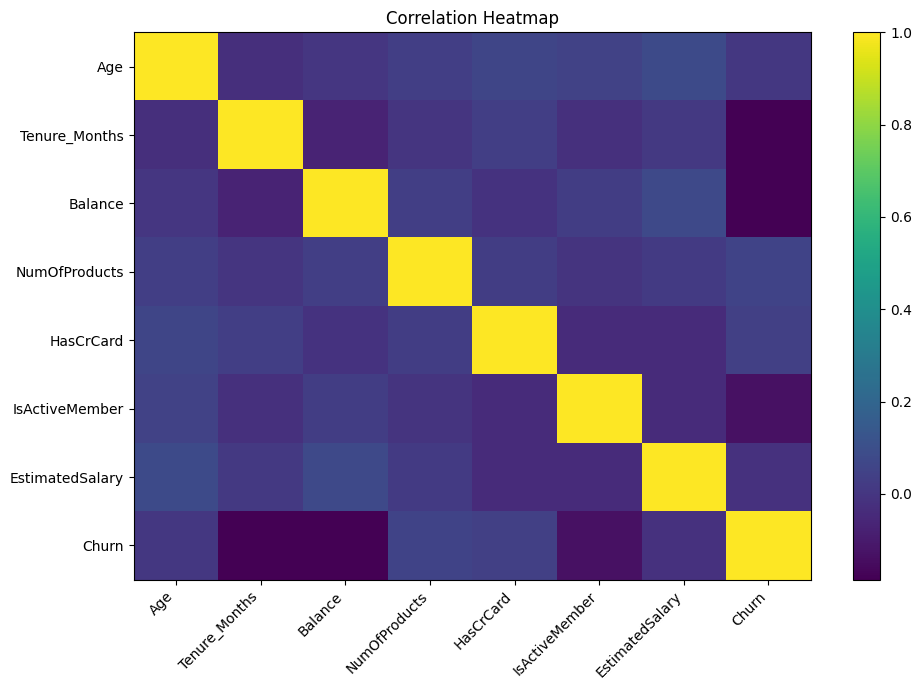

In [22]:
# Correlation Heatmap

plt.figure(figsize=(10, 7))

plt.imshow(correlation, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.index)),
    correlation.index
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [23]:
# Correlation of numerical variables with Churn

churn_correlation = correlation["Churn"].sort_values(
    ascending=False
)

print("Correlation with Churn:")
print(churn_correlation)

Correlation with Churn:
Churn              1.000000
NumOfProducts      0.054587
HasCrCard          0.036841
Age                0.007784
EstimatedSalary   -0.016949
IsActiveMember    -0.131507
Tenure_Months     -0.181039
Balance           -0.185596
Name: Churn, dtype: float64


In [24]:
# Churn rate by key customer segments

print("Churn Rate by Active Membership:")
print(
    df.groupby("IsActiveMember")["Churn"]
    .mean()
    .mul(100)
    .round(2)
)

print("\nChurn Rate by Credit Card:")
print(
    df.groupby("HasCrCard")["Churn"]
    .mean()
    .mul(100)
    .round(2)
)

print("\nChurn Rate by Number of Products:")
print(
    df.groupby("NumOfProducts")["Churn"]
    .mean()
    .mul(100)
    .round(2)
)

Churn Rate by Active Membership:
IsActiveMember
0    3.4
1    0.0
Name: Churn, dtype: float64

Churn Rate by Credit Card:
HasCrCard
0    1.22
1    2.17
Name: Churn, dtype: float64

Churn Rate by Number of Products:
NumOfProducts
1    1.63
2    0.77
3    0.76
4    3.85
Name: Churn, dtype: float64


In [25]:
# Final Business Insights

total_customers = len(df)
churned_customers = df["Churn"].sum()
churn_rate = df["Churn"].mean() * 100

print("CUSTOMER CHURN ANALYSIS - KEY INSIGHTS")
print("=" * 50)

print(f"Total Customers: {total_customers}")
print(f"Churned Customers: {churned_customers}")
print(f"Overall Churn Rate: {churn_rate:.2f}%")

print("\nKey Findings:")
print("1. The overall customer churn rate is 1.70%.")

print("2. Customers with 4 products have the highest "
      "observed product-level churn rate at 3.85%.")

print("3. Customers with 2 and 3 products show lower "
      "observed churn rates than customers with 1 or 4 products.")

print("4. Churn patterns should be interpreted carefully "
      "because only 17 customers in the dataset are marked as churned.")

print("5. Customer activity, tenure, balance, product usage, "
      "and other demographic factors can be evaluated together "
      "to identify potential retention opportunities.")

CUSTOMER CHURN ANALYSIS - KEY INSIGHTS
Total Customers: 1000
Churned Customers: 17
Overall Churn Rate: 1.70%

Key Findings:
1. The overall customer churn rate is 1.70%.
2. Customers with 4 products have the highest observed product-level churn rate at 3.85%.
3. Customers with 2 and 3 products show lower observed churn rates than customers with 1 or 4 products.
4. Churn patterns should be interpreted carefully because only 17 customers in the dataset are marked as churned.
5. Customer activity, tenure, balance, product usage, and other demographic factors can be evaluated together to identify potential retention opportunities.


# Business Recommendations

Based on the customer churn analysis, the following recommendations can be considered:

1. **Monitor customers with multiple products:**  
   Customers with four products show the highest observed churn rate. Their product experience should be reviewed to identify possible service or usability issues.

2. **Focus on customer engagement:**  
   Customer activity status should be monitored because engagement can be an important indicator of retention.

3. **Early-tenure monitoring:**  
   Customers in the early stages of their relationship can be monitored closely and provided with onboarding and engagement support.

4. **Segment-based retention:**  
   Retention strategies should be designed according to customer characteristics such as age, tenure, balance, product usage, and salary segment.

5. **Use data-driven customer retention:**  
   Regular churn monitoring can help identify potentially vulnerable customer segments and support proactive retention campaigns.

6. **Collect more churn observations:**  
   Since the current dataset contains only 17 churned customers, additional historical data would improve the reliability of churn analysis.

# Conclusion

This Customer Churn Analysis project used Python to explore customer behavior and identify patterns associated with churn.

The dataset contains 1,000 customers, of which 17 customers are marked as churned, resulting in an overall churn rate of 1.70%.

The analysis examined customer age, tenure, balance, number of products, credit card ownership, active membership, and estimated salary.

The exploratory analysis highlighted differences in churn rates across customer segments, particularly product usage, balance, tenure, activity status, and salary groups.

The findings can help organizations identify potentially vulnerable customer segments and design targeted customer retention strategies.

However, the relatively small number of churned customers means that the findings should be interpreted carefully. A larger historical dataset would provide stronger evidence for identifying reliable churn patterns.